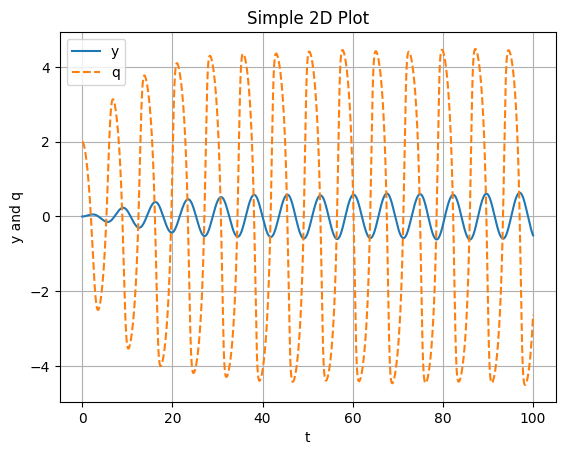

Starting training with learning rate: 0.001 for 60000 epochs.
Epoch: 0, Data Loss1: 6.498150825500488, Data Loss2: 2.9398856163024902, Data Loss: 9.43803596496582, Physics Loss: 0.5456559658050537,  CLo: 1.9990004301071167, Total Loss: 9.983692169189453
Epoch: 1000, Data Loss1: 3.241184711456299, Data Loss2: 2.9264018535614014, Data Loss: 6.167586326599121, Physics Loss: 0.06966764479875565,  CLo: 1.8531575202941895, Total Loss: 6.2372541427612305
Epoch: 2000, Data Loss1: 3.208855390548706, Data Loss2: 2.8552663326263428, Data Loss: 6.064121723175049, Physics Loss: 0.06827375292778015,  CLo: 1.4017213582992554, Total Loss: 6.132395267486572
Epoch: 3000, Data Loss1: 3.2084646224975586, Data Loss2: 2.795050859451294, Data Loss: 6.003515243530273, Physics Loss: 0.1345662623643875,  CLo: 0.6992533206939697, Total Loss: 6.1380815505981445
Epoch: 4000, Data Loss1: 3.1621594429016113, Data Loss2: 2.7921810150146484, Data Loss: 5.95434045791626, Physics Loss: 0.08654244244098663,  CLo: 0.50367

ValueError: too many values to unpack (expected 3)

In [1]:
import tensorflow as tf
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from math import sqrt, pi
class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.hidden_layers1 = [tf.keras.layers.Dense(256, activation='tanh') for _ in range(6)]
        self.output_layer1 = tf.keras.layers.Dense(2)  # 一个输出
        self.hidden_layers2 = [tf.keras.layers.Dense(128, activation='sigmoid') for _ in range(6)]
        self.output_layer2 = tf.keras.layers.Dense(1)  # 一个输出
        self.CLo = tf.Variable(2.0, trainable=True, dtype=tf.float32)
    def call(self, t):
        X = t
        for layer in self.hidden_layers1:
            X = layer(X)
        yq = self.output_layer1(X)
        
        CC = t
        for layer in self.hidden_layers2:
            CC = layer(CC)
        CC = self.output_layer2(CC)
        return tf.concat([yq, CC], axis=1) 
    
def mean_absolute_error(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def physics_loss(model, t, A, B, C, D, E, G, H):
    # 将标量常量转换为 tf.constant
    A = tf.constant(A, dtype=tf.float32)
    B = tf.constant(B, dtype=tf.float32)
    C = tf.constant(C, dtype=tf.float32)
    D = tf.constant(D, dtype=tf.float32)
    E = tf.constant(E, dtype=tf.float32)
    G = tf.constant(G, dtype=tf.float32)
    H = tf.constant(H, dtype=tf.float32)
    CLo = model.CLo  # 使用模型中的 CLo 和 CD
    
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)  # 显式监视 t
        # 前向传播计算
        YY = model(t)
        y = YY[:, 0:1]
        q = YY[:, 1:2] 
        CD = YY[:, 2:3]
        # 计算 y 对 t 和 x 的一阶导数
        dy_dt = tape.gradient(y, t)
        dq_dt = tape.gradient(q, t)
        # 计算二阶导数
        dy_dtt = tape.gradient(dy_dt, t)
        dq_dtt = tape.gradient(dq_dt, t)
    # 计算完成后删除tape
    del tape
    
    # 构建残差
    residual_phy1 = dy_dtt + A * dy_dt + B * y - C * tf.sqrt(D + dy_dt ** 2) * (CLo * E * q - CD * dy_dt)
    residual_phy2 = dq_dtt + G * (q ** 2 - 1) * dq_dt + q - H * dy_dtt
    # 计算残差的平均绝对误差
    loss = mean_absolute_error(residual_phy1, tf.zeros_like(residual_phy1)) + mean_absolute_error(residual_phy2, tf.zeros_like(residual_phy2))
    return loss


def data_loss(y_true, y_pred):
    y_true = tf.convert_to_tensor(y_true, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)
    loss_y = mean_absolute_error(y_true, y_pred)
    return loss_y

def generate_labeled_data():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32)  
    CLo_data = data_w["CLo_values"].flatten().astype(np.float32) 
    CD_data = data_w["CD_values"].flatten().astype(np.float32) 
    valid_indices = (t_data >= 0) & (t_data <= 100)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices]
    CLo_data_filtered = CLo_data[valid_indices] 
    CD_data_filtered = CD_data[valid_indices] 
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs, CLo_data_filtered, CD_data_filtered

def generate_unlabeled_data(t_range, num_samples):
    # 在指定范围内随机生成时间和空间位置
    t_random = np.random.uniform(t_range[0], t_range[1], num_samples)  # 在t范围内生成随机值
    inputs = t_random
    return inputs


def train_with_multiple_lrs(model, t_data, yq_data, t_unlabeled, A, B, C, D, E, G, H, lr_schedule, epochs_per_lr):   
    data_losses1 = []
    data_losses2 = []
    data_losses = []
    physics_losses = []
    total_losses = []
    CLo_values = []  # 用于保存每个epoch的 CLo 值
   # 转换为二维张量
    t_unlabeled = tf.convert_to_tensor(t_unlabeled, dtype=tf.float32)
    t_unlabeled = tf.expand_dims(t_unlabeled, axis=-1)  # 确保是二维的

    t_data = tf.convert_to_tensor(t_data, dtype=tf.float32)
    t_data = tf.expand_dims(t_data, axis=-1)  # 确保是二维的

    t_combined = tf.concat([t_unlabeled, t_data], axis=0)

    # 使用不同学习率进行多阶段训练
    for lr, epochs in zip(lr_schedule, epochs_per_lr):
        print(f"Starting training with learning rate: {lr} for {epochs} epochs.")
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        for epoch in range(epochs):
            with tf.GradientTape() as tape:
                yq_pred = model(t_data)
                loss_data1 = 10*data_loss(yq_pred[:, 0:1], yq_data[:, 0:1])  # 访问 y 的部分
                loss_data2 = data_loss(yq_pred[:, 1:2], yq_data[:, 1:2])  # 访问 q 的部分
                loss_data = (loss_data1 + loss_data2)
                loss_physics = physics_loss(model, tf.convert_to_tensor(t_combined, dtype=tf.float32), A, B, C, D, E, G, H)
                total_loss = loss_data + loss_physics
            gradients = tape.gradient(total_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            data_losses1.append(loss_data1.numpy())
            data_losses2.append(loss_data2.numpy())
            data_losses.append(loss_data.numpy())
            physics_losses.append(loss_physics.numpy())
            total_losses.append(total_loss.numpy())
            CLo_values.append(model.CLo.numpy())
            if epoch % 1000 == 0:
                print(f'Epoch: {epoch}, Data Loss1: {loss_data1.numpy()}, Data Loss2: {loss_data2.numpy()}, Data Loss: {loss_data.numpy()}, Physics Loss: {loss_physics.numpy()},  CLo: {model.CLo.numpy()}, Total Loss: {total_loss.numpy()}')
    np.savetxt("data_losses1.txt", data_losses1, delimiter=',')
    np.savetxt("data_losses2.txt", data_losses2, delimiter=',')
    np.savetxt("data_losses.txt", data_losses, delimiter=',')
    np.savetxt("physics_losses.txt", physics_losses, delimiter=',')
    np.savetxt("CLo_values.txt", CLo_values, delimiter=',')  # 保存为文本文件 
    np.savetxt("total_losses.txt", total_losses, delimiter=',')           
    return data_losses, physics_losses, total_losses, CLo_values


if __name__ == "__main__":

    t_data, yq_data, CLo, CD = generate_labeled_data()
    
    plt.plot(t_data, yq_data[:,0], label='y')  # 绘制曲线
    plt.plot(t_data, yq_data[:,1], label='q', linestyle='--') 
    plt.xlabel('t')  # x 轴标签
    plt.ylabel('y and q')  # y 轴标签
    plt.title('Simple 2D Plot')  # 图形标题
    plt.legend()  # 显示图例
    plt.grid(True)  # 显示网格
    plt.show()  # 显示图形
    
    t_unlabeled = generate_unlabeled_data((0, 100), 1)
    
    font = {'family': 'serif',
        'color': 'darkred',
        'weight': 'normal',
        'size': 10,
       }
    
    # 常量和参数
    Dex=0.0554
    rou = 998.2
    L=0.4432
    M1=2.53
    K=453.0*2
    Ee=0.006
    St=0.17
    C_a=1
    E_w=0.3
    S_w=12
    m_a=0.25*C_a*pi*rou*Dex**2
    m_s=M1/L
    m=m_s+m_a
    W_n=sqrt(K/(m_s+m_a))
    Ur=7
    Uex=Ur*W_n*Dex/(2*pi)
    W_s=2*pi*St*Uex/Dex
    deta = W_n/ W_s; #%1/(St*Ur(i));
    m1=m_s/(0.25*pi*rou*Dex**2)
    gz=1/W_n;
    A=2*Ee*deta;
    B=deta**2;
    C=2/(pi*(C_a+m1));
    D=(1/(2*pi*St))**2;
    E=1/(4*pi*St);
    G=E_w;
    H=S_w;

    model = PINN()

    # 定义不同阶段的学习率和相应的训练轮数
    lr_schedule = [0.001,0.0005,0.0001,0.00005,0.00001]
    epochs_per_lr = [60000,60000,40000,40000,40000]

    data_losses, physics_losses, total_losses = train_with_multiple_lrs(
        model, t_data, yq_data, t_unlabeled, A, B, C, D, E, G, H,
        lr_schedule, epochs_per_lr
    )
    
  

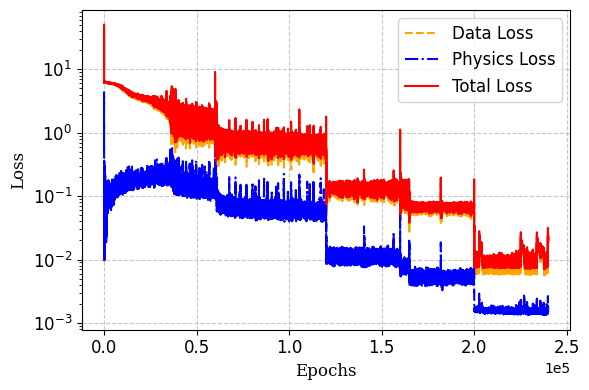

In [2]:
###___________________LOSS______________________#####

import matplotlib.ticker as mticker

font = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}

epochs = np.arange(1, 240001, 1)  # 1到10000，步长为1
# Load the saved values of CD and CLo for each epoch

data_losses1 = np.loadtxt("data_losses1.txt", delimiter=',')
data_losses2 = np.loadtxt("data_losses2.txt", delimiter=',')
data_losses = np.loadtxt("data_losses.txt", delimiter=',')

physics_losses = np.loadtxt("physics_losses.txt", delimiter=',')
total_losses = np.loadtxt("total_losses.txt", delimiter=',')

# 绘制损失函数
plt.figure(figsize=(6, 4))
# 使用不同的线型和颜色
plt.plot(epochs, data_losses, label='Data Loss', color='orange', linestyle='--')  # 虚线
plt.plot(epochs, physics_losses, label='Physics Loss', color='blue', linestyle='-.')  # 点划线
plt.plot(epochs, total_losses, label='Total Loss', color='red', linestyle='-')  # 点线
plt.yscale('log')  # 将 Y 轴设置为对数坐标
plt.title('', fontdict=font)
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().xaxis.get_major_formatter().set_scientific(True)
plt.gca().xaxis.get_major_formatter().set_powerlimits((0, 1))

plt.xlabel('Epochs', fontdict=font)
plt.ylabel('Loss', fontdict=font)

plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("LOSS.png", format="png", dpi=300)  # 保存图片
plt.show()

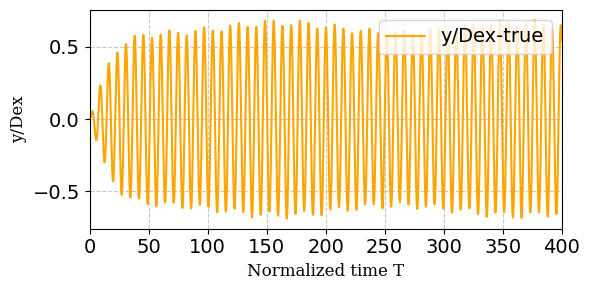

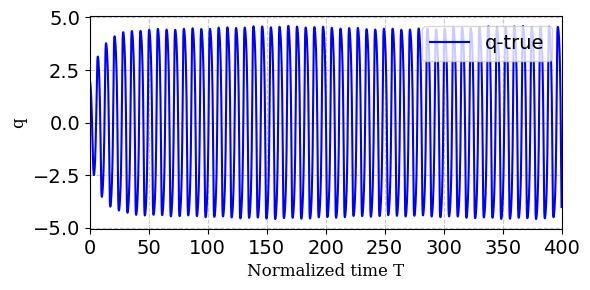

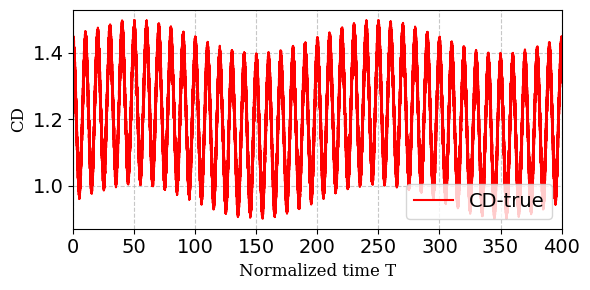

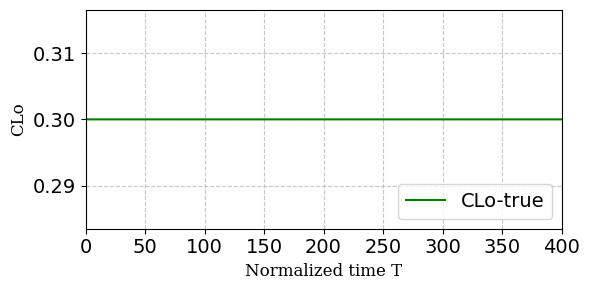

In [3]:
# 进行预测
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
def generate_labeled_data2():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32) 
    CLo_data = data_w["CLo_values"].flatten().astype(np.float32) 
    CD_data = data_w["CD_values"].flatten().astype(np.float32) 
    
    valid_indices = (t_data >= 0) & (t_data <= 400)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices] 
    CLo_data_filtered = CLo_data[valid_indices]
    CD_data_filtered = CD_data[valid_indices]
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    CLo_data_filtered = tf.expand_dims(CLo_data_filtered, axis=-1)
    CD_data_filtered = tf.expand_dims(CD_data_filtered, axis=-1)
    
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs, CLo_data_filtered, CD_data_filtered    

inputs2, outputs2,CLo_2, CD_2 = generate_labeled_data2()


inputs2 = tf.convert_to_tensor(inputs2, dtype=tf.float32)
inputs2 = tf.expand_dims(inputs2, axis=-1)  # 确保是二维的


#y = YY[:, 0:1]   q = YY[:, 1:2] CLo = YY[:, 2:3]  # 使用模型中的 CLo 和 CD   CD = YY[:, 3:4]

font = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}
# 绘制损失函数
plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,0], label='y/Dex-true', color='orange', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('y/Dex', fontdict=font)
plt.legend(loc='upper right', fontsize=14)  # 设置标签位置
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("y.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,1], label='q-true', color='blue', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('q', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("q.png", format="png", dpi=300)  # 保存图片
plt.show()


plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CD_2, label='CD-true', color='red', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('CD', fontdict=font)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CD.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CLo_2, label='CLo-true', color='green', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('CLo', fontdict=font)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CLo.png", format="png", dpi=300)  # 保存图片
plt.show()


313/313 [==============================] - 0s 1ms/step


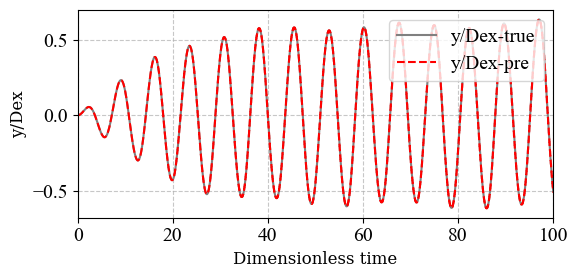

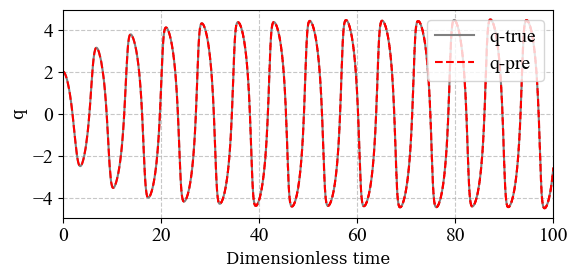

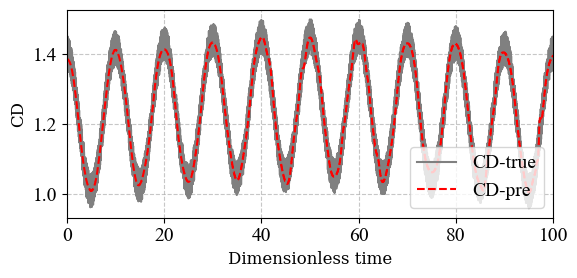

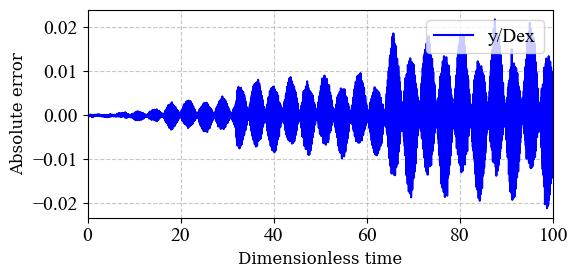

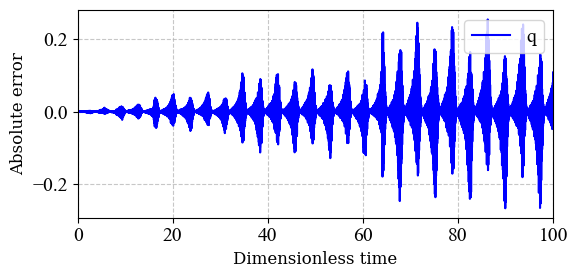

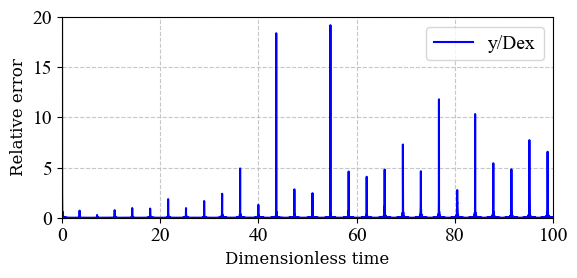

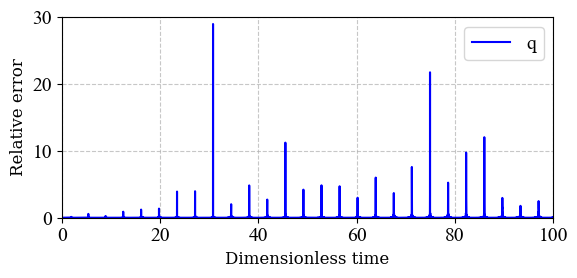

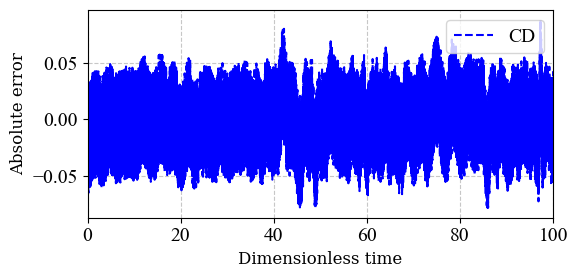

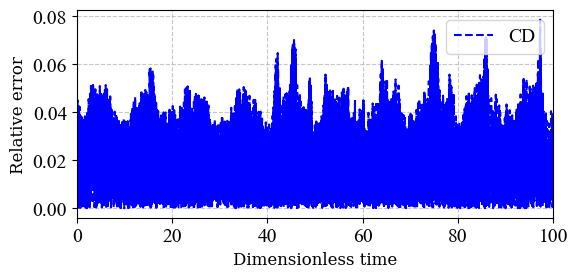

In [12]:
# 进行预测
def generate_labeled_data2():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32) 
    CLo_data = data_w["CLo_values"].flatten().astype(np.float32) 
    CD_data = data_w["CD_values"].flatten().astype(np.float32) 
    
    valid_indices = (t_data >= 0) & (t_data <= 100)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices] 
    CLo_data_filtered = CLo_data[valid_indices]
    CD_data_filtered = CD_data[valid_indices]
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    CLo_data_filtered = tf.expand_dims(CLo_data_filtered, axis=-1)
    CD_data_filtered = tf.expand_dims(CD_data_filtered, axis=-1)
    
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs, CLo_data_filtered, CD_data_filtered    

inputs2, outputs2,CLo_2, CD_2 = generate_labeled_data2()


inputs2 = tf.convert_to_tensor(inputs2, dtype=tf.float32)
inputs2 = tf.expand_dims(inputs2, axis=-1)  # 确保是二维的
predictions = model.predict(inputs2)

#y = YY[:, 0:1]   q = YY[:, 1:2] CLo = YY[:, 2:3]  # 使用模型中的 CLo 和 CD   CD = YY[:, 3:4]

ERROR= predictions[:, 0:2]-outputs2[:, 0:2]
R_ERROR=abs((predictions[:, 0:2]-outputs2[:, 0:2])/outputs2[:, 0:2])
CD_ERROR= predictions[:, 2:3]-CD_2
CD_R_ERROR= abs((predictions[:,2:3]-CD_2)/CD_2)


# 绘制损失函数
plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,0], label='y/Dex-true', color='grey', linestyle='-')  # 虚线
plt.plot(inputs2, predictions[:,0], label='y/Dex-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('y/Dex', fontdict=font)
plt.legend(loc='upper right', fontsize=14)  # 设置标签位置
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("y-pre.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,1], label='q-true', color='grey', linestyle='-')  # 虚线
plt.plot(inputs2, predictions[:,1], label='q-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('q', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("q-pre.png", format="png", dpi=300)  # 保存图片
plt.show()


plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CD_2, label='CD-true', color='grey', linestyle='-')  # 虚线
plt.plot(inputs2, predictions[:,2], label='CD-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('CD', fontdict=font)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CD-pre.png", format="png", dpi=300)  # 保存图片
plt.show()
 
plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, ERROR[:,0], label='y/Dex', color='blue', linestyle='-')  # 虚线

plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Absolute error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Absolute error1.png", format="png", dpi=300)  # 保存图片
plt.show()


plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色

plt.plot(inputs2, ERROR[:,1], label='q', color='blue', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Absolute error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Absolute error2.png", format="png", dpi=300)  # 保存图片
plt.show()





plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, R_ERROR[:,0], label='y/Dex', color='blue', linestyle='-')  # 虚线

plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Relative error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.ylim(0, 20)  # 将 X 轴限制在 0 到 20000 之间
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Relative error1.png", format="png", dpi=300)  # 保存图片
plt.show()



plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色

plt.plot(inputs2, R_ERROR[:,1], label='q', color='blue', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Relative error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.ylim(0, 30)  # 将 X 轴限制在 0 到 20000 之间
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Relative error2.png", format="png", dpi=300)  # 保存图片
plt.show()


plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CD_ERROR, label='CD', color='blue', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Absolute error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Absolute error-CD.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CD_R_ERROR, label='CD', color='blue', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('Relative error', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("Relative error-CD.png", format="png", dpi=300)  # 保存图片
plt.show()






313/313 [==============================] - 0s 934us/step


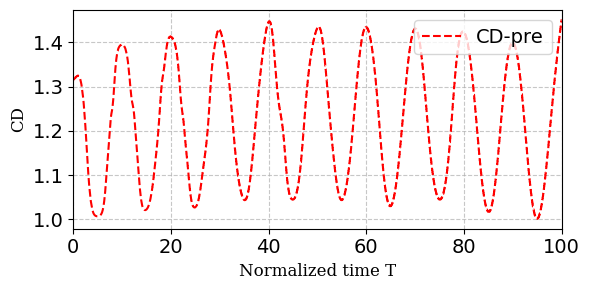

In [6]:
# 进行预测
def generate_labeled_data2():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32) 
    CLo_data = data_w["CLo_values"].flatten().astype(np.float32) 
    CD_data = data_w["CD_values"].flatten().astype(np.float32) 
    
    valid_indices = (t_data >= 0) & (t_data <= 100)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices] 
    CLo_data_filtered = CLo_data[valid_indices]
    CD_data_filtered = CD_data[valid_indices]
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    CLo_data_filtered = tf.expand_dims(CLo_data_filtered, axis=-1)
    CD_data_filtered = tf.expand_dims(CD_data_filtered, axis=-1)
    
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs, CLo_data_filtered, CD_data_filtered    

inputs2, outputs2,CLo_2, CD_2 = generate_labeled_data2()


inputs2 = tf.convert_to_tensor(inputs2, dtype=tf.float32)
inputs2 = tf.expand_dims(inputs2, axis=-1)  # 确保是二维的
predictions = model.predict(inputs2)

#y = YY[:, 0:1]   q = YY[:, 1:2] CLo = YY[:, 2:3]  # 使用模型中的 CLo 和 CD   CD = YY[:, 3:4]




plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, predictions[:,2], label='CD-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('CD', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.show()





Pearson correlation coefficient: 0.9999230082519193
决定系数 (R²): 0.9998460224315678


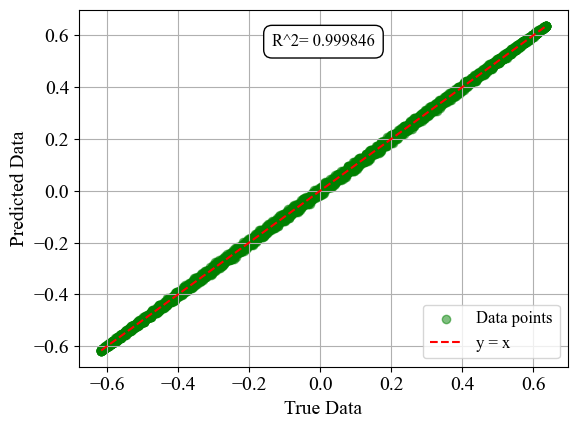

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 设置字体
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # 设定字体大小为14

# 创建图形
plt.figure(figsize=(6, 4.5))

# 绘制真实值和预测值的散点图
plt.scatter(outputs2[:,0], predictions[:,0], color="green", alpha=0.5, label="Data points")
y2_data =outputs2[:,0]
Y_PRE = predictions[:,0]
# 计算皮尔逊相关系数
correlation, _ = pearsonr(y2_data, Y_PRE)
print(f"Pearson correlation coefficient: {correlation}")
r_squared = correlation ** 2
print(f"决定系数 (R²): {r_squared}")
# 在图中添加相关系数
plt.text(0.5, 0.9, f"R^2= {r_squared:.6f}", fontsize=12, ha='center', 
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# 绘制y = x线（完美预测的参考线）
plt.plot([min(y2_data), max(y2_data)], [min(y2_data), max(y2_data)], color="red", linestyle="--", label="y = x")

# 添加标签和图例
plt.xlabel("True Data")
plt.ylabel("Predicted Data")
plt.title("")
plt.xticks(fontsize=14)  # 设置x轴刻度字体大小
plt.yticks(fontsize=14)  # 设置y轴刻度字体大小
plt.legend(loc='lower right', fontsize=12)  #
plt.grid()
plt.tight_layout()
# 保存图像
plt.savefig("预测精度.png", dpi=300)

# 显

313/313 [==============================] - 0s 971us/step


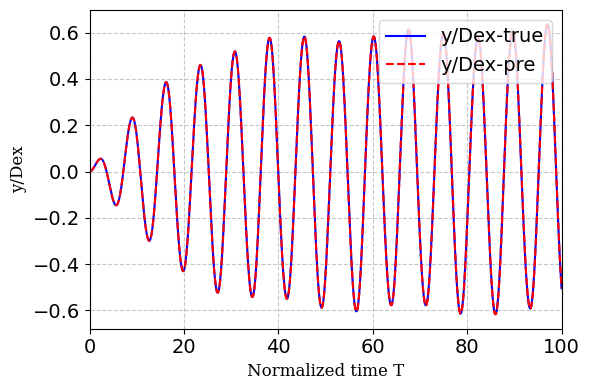

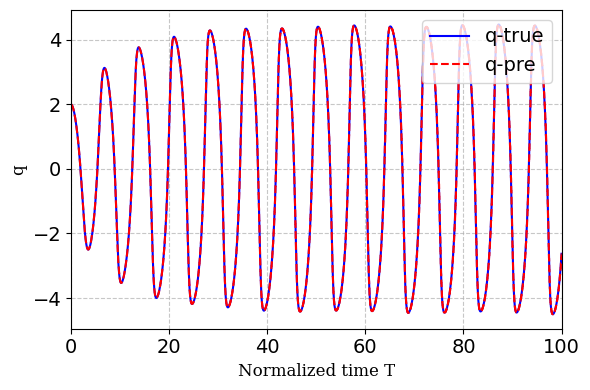

In [8]:
# 进行预测
def generate_labeled_data2():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32)  
    valid_indices = (t_data >= 0) & (t_data <= 100)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices] 
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    
    
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs    

inputs2, outputs2 = generate_labeled_data2()
inputs2 = tf.convert_to_tensor(inputs2, dtype=tf.float32)
inputs2 = tf.expand_dims(inputs2, axis=-1)  # 确保是二维的
predictions = model.predict(inputs2)

# 绘制损失函数
plt.figure(figsize=(6, 4))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,0], label='y/Dex-true', color='blue', linestyle='-')  # 虚线
plt.plot(inputs2, predictions[:,0], label='y/Dex-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('y/Dex', fontdict=font)
plt.legend(loc='upper right', fontsize=14)  # 设置标签位置
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("y-pre.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 4))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,1], label='q-true', color='blue', linestyle='-')  # 虚线
plt.plot(inputs2, predictions[:,1], label='q-pre', color='red', linestyle='--')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 100)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Normalized time T', fontdict=font)
plt.ylabel('q', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("q-pre.png", format="png", dpi=300)  # 保存图片
plt.show()


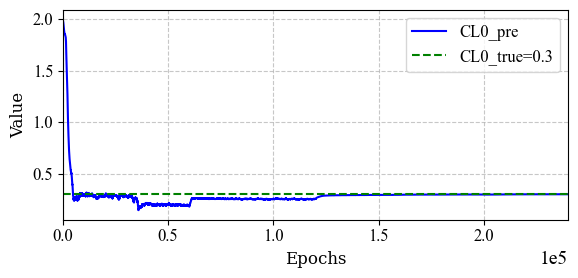

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Load the saved values of CD and CLo for each epoch
CLo_values = np.loadtxt("CLo_values.txt", delimiter=',')


font = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}

    # 绘制损失函数
plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(epochs,CLo_values, label='CL0_pre', color='blue',linestyle='-')


plt.axhline(y=0.3, label='CL0_true=0.3', color='green', linestyle='--')  # 添加水平线

plt.xlim(0, 240000)  # 将 X 轴限制在 0 到 20000 之间
plt.title('', fontdict=font)
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().xaxis.get_major_formatter().set_scientific(True)
plt.gca().xaxis.get_major_formatter().set_powerlimits((0, 1))

plt.xlabel('Epochs', fontdict=font)
plt.ylabel('Value', fontdict=font)

plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.legend(fontsize=12,loc='upper right')  # 将图例位置设置为右上角
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CD AND CLo.png", format="png", dpi=300)  # 保存图片
plt.show()


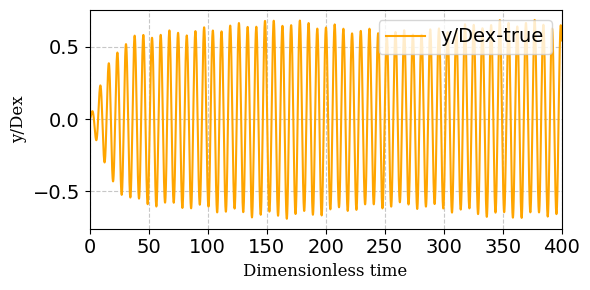

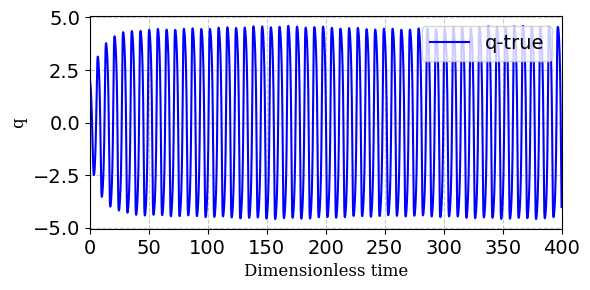

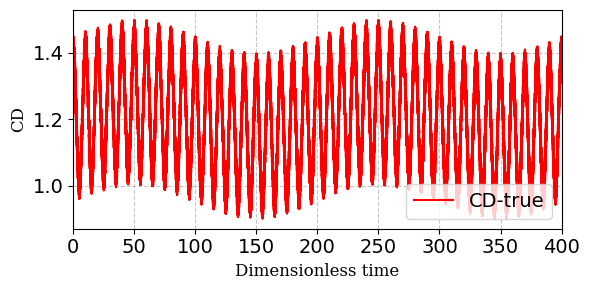

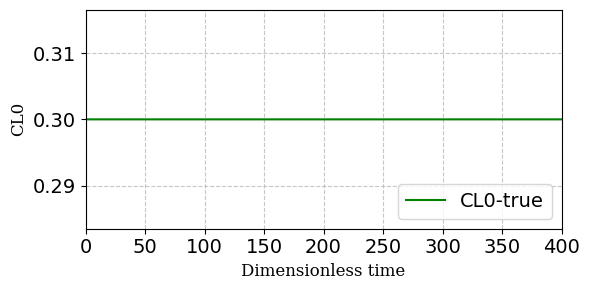

In [1]:
# 进行预测
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
def generate_labeled_data2():
    data_w = loadmat("2DVIV-fuction.mat")
    t_data = data_w["t"].flatten().astype(np.float32)  # 将数据转换为 float32
    y_data = data_w["Y_CL"].flatten().astype(np.float32)
    q_data = data_w["Q_CL"].flatten().astype(np.float32) 
    CLo_data = data_w["CLo_values"].flatten().astype(np.float32) 
    CD_data = data_w["CD_values"].flatten().astype(np.float32) 
    
    valid_indices = (t_data >= 0) & (t_data <= 400)
    t_data_filtered = t_data[valid_indices]
    y_data_filtered = y_data[valid_indices]
    q_data_filtered = q_data[valid_indices] 
    CLo_data_filtered = CLo_data[valid_indices]
    CD_data_filtered = CD_data[valid_indices]
    y_data_filtered = tf.expand_dims(y_data_filtered, axis=-1)
    q_data_filtered = tf.expand_dims(q_data_filtered, axis=-1)
    CLo_data_filtered = tf.expand_dims(CLo_data_filtered, axis=-1)
    CD_data_filtered = tf.expand_dims(CD_data_filtered, axis=-1)
    
    inputs = t_data_filtered
    outputs = tf.concat([y_data_filtered, q_data_filtered], axis=1)
    return inputs, outputs, CLo_data_filtered, CD_data_filtered    

inputs2, outputs2,CLo_2, CD_2 = generate_labeled_data2()


inputs2 = tf.convert_to_tensor(inputs2, dtype=tf.float32)
inputs2 = tf.expand_dims(inputs2, axis=-1)  # 确保是二维的


#y = YY[:, 0:1]   q = YY[:, 1:2] CLo = YY[:, 2:3]  # 使用模型中的 CLo 和 CD   CD = YY[:, 3:4]

font = {'family': 'serif', 'color': 'black', 'weight': 'normal', 'size': 12}
# 绘制损失函数
plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,0], label='y/Dex-true', color='orange', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('y/Dex', fontdict=font)
plt.legend(loc='upper right', fontsize=14)  # 设置标签位置
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("y.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, outputs2[:,1], label='q-true', color='blue', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('q', fontdict=font)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("q.png", format="png", dpi=300)  # 保存图片
plt.show()


plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CD_2, label='CD-true', color='red', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('CD', fontdict=font)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CD.png", format="png", dpi=300)  # 保存图片
plt.show()

plt.figure(figsize=(6, 3))
# 使用不同的线型和颜色
plt.plot(inputs2, CLo_2, label='CL0-true', color='green', linestyle='-')  # 虚线
plt.title('', fontdict=font)
plt.xlim(0, 400)  # 将 X 轴限制在 0 到 20000 之间
plt.xlabel('Dimensionless time', fontdict=font)
plt.ylabel('CL0', fontdict=font)
plt.legend(loc='lower right', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.7)  # 更加淡化的网格
plt.savefig("CLo.png", format="png", dpi=300)  # 保存图片
plt.show()
